# Энерговыделение в бериллиевой мишени — как читать результат

Файл `.npz`, к которому этот ноутбук, содержит **распределение тепловыделения в мишени**,
посчитанное по трекам частиц из GEANT4/SRIM.

### Постановка

* Протонный пучок летит вдоль оси **x** и тормозится в бериллиевой мишени.
* Смоделировано фиксированное число протонов (`n_sim_protons`), энерговыделение
  нормировано **на один протон**, затем свёрнуто с реальным поперечным профилем пучка
  (эллиптический гаусс `σy × σz`) и умножено на число протонов, задаваемое параметрами
  ускорителя (ток в импульсе, длительность импульса, частота повторения).
* Учтены **первичные** частицы (сами протоны) и **вторичные** (протоны отдачи, дейтроны,
  альфа-частицы, ядра отдачи и т.д.) — они лежат и по отдельности, и в сумме.
* Мишенная сборка — **вращающееся колесо** с несколькими бериллиевыми болванками:
  соседние импульсы приходят в разные болванки, и за время импульса болванка успевает
  сместиться поперёк пучка. Если в расчёте задана скорость, энерговыделение **размазано
  по траектории движения** — распределение вытянуто вдоль оси `y`.

### Система координат

| Ось | Смысл | Диапазон |
|---|---|---|
| `x` | вдоль пучка, вглубь мишени | толщина мишени (мм) |
| `y`, `z` | поперёк пучка | радиус мишени (мм) |

Начало координат — на оси пучка, она же ось круглой мишени. Все координаты в файле — **в миллиметрах**.

### Что именно лежит в файле

Основная величина — **поверхностная плотность** на плоскости Y/Z, т.е. энерговыделение,
проинтегрированное по всей глубине мишени:

$$ q(y,z) \;=\; \int \varepsilon(x,y,z)\, dx \qquad [\text{Вт/см}^2 \text{ или Дж/мм}^2 \ldots] $$

Плюс профиль по глубине, полярное представление для круглой мишени и полный паспорт расчёта.
Ниже — чтение, проверка баланса энергии и выгрузка файлов для COMSOL/ANSYS.

In [1]:
from pathlib import Path
import json

import numpy as np
import matplotlib.pyplot as plt

# ======================= ЧТО ПОМЕНЯТЬ =======================
NPZ = Path("results/wall_load_20MeV.npz")   # файл с результатом расчёта
EXPORT_DIR = Path("export")                 # куда положить файлы для COMSOL/ANSYS
# ============================================================

data = np.load(NPZ)
meta = json.loads(str(data["meta_json"]))

print(f"файл       : {NPZ}  ({NPZ.stat().st_size / 2**20:.1f} МБ)")
print(f"рассчитано : {meta['created']}")
print(f"источник   : {meta['grids']['primary']['source']}")

файл       : results/wall_load_20MeV.npz  (45.8 МБ)
рассчитано : 2026-09-24 14:56:23
источник   : Effective traks/primary_de_points_20_MeV.csv


## 1. Что внутри файла

`.npz` — это zip-архив из именованных массивов NumPy: `data["имя"]` возвращает массив,
`data.files` — список имён. Строки (единицы измерения, метаданные) лежат как
нуль-мерные массивы и читаются через `str(...)`.

In [2]:
DESCR = {
    "y_mm": "центры бинов по y, мм",
    "z_mm": "центры бинов по z, мм",
    "y_edges_mm": "границы бинов по y (для pcolormesh), мм",
    "z_edges_mm": "границы бинов по z, мм",
    "q_primary": "поверхностная плотность, первичные частицы",
    "q_secondary": "поверхностная плотность, вторичные частицы",
    "q_total": "поверхностная плотность, СУММА — основная величина",
    "r_mm": "радиус полярной сетки, мм",
    "phi_rad": "азимут полярной сетки, рад (0..2pi)",
    "q_polar_total": "q_total в полярных координатах [r, phi]",
    "q_polar_primary": "то же, первичные",
    "q_polar_secondary": "то же, вторичные",
    "q_radial_mean": "радиальный профиль (среднее по азимуту)",
    "x_mm": "центры вокселей вдоль пучка, мм",
    "eps_axis_primary": "объёмная плотность НА ОСИ пучка, первичные",
    "eps_axis_secondary": "объёмная плотность на оси, вторичные",
    "eps_axis_total": "объёмная плотность на оси, сумма",
    "lin_depth_primary": "dE/dx по всему сечению, первичные",
    "lin_depth_secondary": "dE/dx по всему сечению, вторичные",
    "lin_depth_total": "dE/dx по всему сечению, сумма — форма источника по глубине",
    "surface_units": "единицы поверхностной плотности",
    "volume_units": "единицы объёмной плотности",
    "linear_units": "единицы линейной плотности (dE/dx)",
    "meta_json": "все параметры расчёта (JSON-строка)",
}

print(f"{'ключ':<20} {'форма':<16} {'тип':<9} описание")
print("-" * 100)
for key in data.files:
    arr = data[key]
    shape = "строка" if arr.ndim == 0 else str(arr.shape)
    print(f"{key:<20} {shape:<16} {str(arr.dtype):<9} {DESCR.get(key, '')}")

ключ                 форма            тип       описание
----------------------------------------------------------------------------------------------------
y_mm                 (1925,)          float64   центры бинов по y, мм
z_mm                 (1925,)          float64   центры бинов по z, мм
y_edges_mm           (1926,)          float64   границы бинов по y (для pcolormesh), мм
z_edges_mm           (1926,)          float64   границы бинов по z, мм
q_primary            (1925, 1925)     float32   поверхностная плотность, первичные частицы
q_secondary          (1925, 1925)     float32   поверхностная плотность, вторичные частицы
q_total              (1925, 1925)     float32   поверхностная плотность, СУММА — основная величина
r_mm                 (400,)           float64   радиус полярной сетки, мм
phi_rad              (720,)           float64   азимут полярной сетки, рад (0..2pi)
q_polar_total        (400, 720)       float32   q_total в полярных координатах [r, phi]
q_polar_primary 

## 2. Паспорт расчёта

Вся информация о том, как получены цифры, лежит в `meta` (она же продублирована
в соседнем `.json`-файле — его можно открыть текстовым редактором).

In [3]:
cfg = meta["config"]
beam, target = cfg["beam"], cfg["target"]
tot = meta["totals"]

print("ПУЧОК")
print(f"  поперечный размер : sigma_y = {beam['sigma_y_mm']} мм, sigma_z = {beam['sigma_z_mm']} мм")
print(f"                      FWHM    = {meta['beam']['fwhm_y_mm']:.2f} x {meta['beam']['fwhm_z_mm']:.2f} мм")
print(f"  режим             : {beam['peak_current_mA']} мА в импульсе, "
      f"{beam['pulse_us']} мкс, {beam['rep_rate_Hz']} Гц")
print(f"  коэф. заполнения  : {beam['duty_cycle']*100:.3f} %  (D = t/T)")
print(f"  скважность        : {1/beam['duty_cycle']:,.1f}        (S = T/t)")
print(f"  средний ток       : {beam['average_current_mA']:.4f} мА")
print(f"  протонов          : {beam['protons_per_pulse']:.4e} за импульс")

print("\nМИШЕННАЯ СБОРКА")
print(f"  диаметр болванки  : {target['diameter_mm']} мм")

motion = meta.get("motion")
rates = meta.get("rates")
if motion:
    if motion["speed_m_per_s"] > 0:
        print(f"  скорость движения : {motion['speed_m_per_s']:,.4g} м/с вдоль оси {motion['axis']}")
        print(f"  путь за импульс   : {motion['sweep_mm']:.2f} мм "
              f"(распределение размазано на эту длину)")
        print(f"  зазор до края     : {motion['edge_gap_mm']:.2f} мм = "
              f"{motion['edge_gap_sigma']:.2f} sigma_y")
    else:
        print(f"  движение          : нет, болванка неподвижна")
    print(f"  предельная скорость: {motion['max_speed_m_per_s']:,.1f} м/с "
          f"(при ней зазор ровно {motion['required_margin_mm']:.2f} мм с обеих сторон)")
if rates:
    print(f"  болванок в сборке : {rates['n_pucks']}")
    print(f"  импульсов в одну  : {rates['hit_rate_Hz']:,.4g} Гц "
          f"(коэф. заполнения {rates['puck_duty_cycle']*100:.4f} %, "
          f"скважность {1/rates['puck_duty_cycle']:,.1f})")
e = meta["grids"]["primary"]["extent_mm"]["x"]
print(f"  толщина слоя      : {e[1]-e[0]:.3f} мм "
      f"(координаты x от {e[0]:.3f} до {e[1]:.3f} мм)")

print("\nСЕТКИ")
for name in ("primary", "secondary"):
    g = meta["grids"].get(name)
    if g:
        v = g["voxel_size_mm"]
        print(f"  воксель ({name:<9}): {v[0]*1e3:.1f} x {v[1]*1e3:.1f} x {v[2]*1e3:.1f} мкм")
og = meta["output_grid"]
print(f"  итоговая решётка   : шаг {og['step_mm']*1e3:.1f} мкм, {og['shape'][0]} x {og['shape'][1]}")

print("\nБАЛАНС ЭНЕРГИИ  (" + meta["totals_units"] + ")")
print(f"  первичные         : {tot['primary']:,.4g}")
print(f"  вторичные         : {tot['secondary']:,.4g}  "
      f"({100*tot['secondary']/tot['primary']:.2f} % от первичных)")
print(f"  ВСЕГО на мишени   : {tot['total_on_target']:,.4g}")
print(f"  ушло за край      : {tot['outside_fraction']*100:.4f} %")

ПУЧОК
  поперечный размер : sigma_y = 3.33 мм, sigma_z = 2.66 мм
                      FWHM    = 7.84 x 6.26 мм
  режим             : 100.0 мА в импульсе, 100.0 мкс, 100.0 Гц
  коэф. заполнения  : 1.000 %  (D = t/T)
  скважность        : 100.0        (S = T/t)
  средний ток       : 1.0000 мА
  протонов          : 6.2415e+13 за импульс

МИШЕННАЯ СБОРКА
  диаметр болванки  : 50.0 мм
  скорость движения : 167 м/с вдоль оси y
  путь за импульс   : 16.70 мм (распределение размазано на эту длину)
  зазор до края     : 16.65 мм = 5.00 sigma_y
  предельная скорость: 167.0 м/с (при ней зазор ровно 16.65 мм с обеих сторон)
  болванок в сборке : 1
  импульсов в одну  : 100 Гц (коэф. заполнения 1.0000 %, скважность 100.0)
  толщина слоя      : 2.600 мм (координаты x от -1.300 до 1.300 мм)

СЕТКИ
  воксель (primary  ): 26.0 x 26.0 x 26.0 мкм
  воксель (secondary): 26.0 x 22.3 x 21.2 мкм
  итоговая решётка   : шаг 26.0 мкм, 1925 x 1925

БАЛАНС ЭНЕРГИИ  (J/импульс)
  первичные         : 120.9
  втори

## 3. Единицы, энергия и мощность

В файле величины могут быть заданы **за импульс** (`J/...`) или как **средняя мощность**
(`W/...`) — смотрите `surface_units`. Исходная физическая величина одна: **энергия,
выделившаяся за один импульс длительностью 100 мкс**. Мощность получается делением этой
энергии на интервал усреднения, и таких интервалов три — это три разных числа для
трёх разных задач:

| # | Интервал усреднения | Что получается | Для чего |
|---|---|---|---|
| 1 | длительность импульса, 100 мкс | мощность **в течение импульса** | нестационарный расчёт внутри импульса, пиковые термонапряжения |
| 2 | период источника, 1/100 Гц = 10 мс | мощность **на всю сборку** | баланс теплосъёма колеса целиком, расход теплоносителя |
| 3 | N периодов (N — число болванок) | мощность **на одну болванку** | стационарная температура конкретной болванки |

Вариант 1 больше варианта 2 ровно в скважность S = T/t = 100 раз
(коэффициент заполнения D = t/T = 1 %). Вариант 3 меньше варианта 2
ровно в N раз: болванка получает импульс не каждый период, а раз за оборот колеса.
**При N = 1 варианты 2 и 3 совпадают** — это случай неподвижной одиночной мишени.

> Карты в файле и всё, что выгружается для COMSOL/ANSYS, нормированы по **варианту 3**
> (на одну болванку). Величины «за импульс» от N не зависят.

In [4]:
# --- разбор единиц -----------------------------------------------------------
surface_units = str(data["surface_units"])          # например 'W/cm2' или 'J/mm2'
kind, den = surface_units.split("/")                # 'W' | 'J'  и  'cm2' | 'mm2'
length = den.rstrip("0123456789")
M_PER_UNIT = {"mm": 1e-3, "cm": 1e-2, "m": 1.0}[length]   # метров в единице длины

# частота попаданий в ОДНУ болванку и её коэффициент заполнения
# (для колеса из N болванок это rep_rate / N; в старых файлах секции rates нет)
rates = meta.get("rates", {"hit_rate_Hz": cfg["beam"]["rep_rate_Hz"],
                           "n_pucks": 1,
                           "puck_duty_cycle": meta["beam"]["duty_cycle"]})
f_hit = rates["hit_rate_Hz"]
duty = rates["puck_duty_cycle"]

# --- координаты в метрах -----------------------------------------------------
y_m = data["y_mm"] * 1e-3
z_m = data["z_mm"] * 1e-3
x_m = data["x_mm"] * 1e-3

# --- поверхностная плотность в СИ -------------------------------------------
q = data["q_total"].astype(np.float64) / M_PER_UNIT**2    # X / м²
q_avg = q * f_hit if kind == "J" else q                   # Вт/м², средняя
q_per_pulse = q_avg / f_hit                               # Дж/м², за импульс
q_in_pulse = q_avg / duty                                 # Вт/м², внутри импульса

# --- проверка баланса --------------------------------------------------------
dy, dz = y_m[1] - y_m[0], z_m[1] - z_m[0]
P_avg = q_avg.sum() * dy * dz                             # Вт, вариант 3
P_meta = tot["total_on_target"] * (f_hit if kind == "J" else 1.0)

tau = cfg["beam"]["pulse_us"] * 1e-6                      # длительность импульса, с
rep = cfg["beam"]["rep_rate_Hz"]                          # частота источника, Гц
N = rates["n_pucks"]                                      # болванок в сборке
E_pulse = P_avg / f_hit                                   # Дж за импульс

print(f"единицы в файле       : {surface_units}  ({'за импульс' if kind == 'J' else 'средняя мощность'})")
print(f"шаг сетки             : {dy*1e3:.4f} x {dz*1e3:.4f} мм")
print(f"болванок в сборке     : {N}")
print()
print(f"ЭНЕРГИЯ ЗА ОДИН ИМПУЛЬС ({cfg['beam']['pulse_us']:g} мкс)")
print(f"  на одну болванку    : {E_pulse:,.3f} Дж")
print()
print(f"МОЩНОСТЬ — та же энергия, разные интервалы усреднения")
print(f"  1) / {cfg['beam']['pulse_us']:g} мкс  (длительность импульса) : "
      f"{E_pulse/tau/1e3:>12,.2f} кВт   в течение импульса")
print(f"  2) / {1e3/rep:g} мс    (период источника)      : "
      f"{E_pulse*rep/1e3:>12,.4f} кВт   на всю сборку")
print(f"  3) / {N*1e3/rep:g} мс    (оборот колеса, N={N})      : "
      f"{E_pulse*f_hit/1e3:>12,.4f} кВт   на одну болванку  <-- в картах")
print()
print(f"ПИКОВАЯ ПЛОТНОСТЬ на стенке")
print(f"  за импульс          : {q_per_pulse.max()/1e4:>12,.2f} Дж/см²")
print(f"  в течение импульса  : {q_in_pulse.max()/1e10:>12,.3f} МВт/см²")
print(f"  на одну болванку    : {q_avg.max()/1e4:>12,.0f} Вт/см²   ({q_avg.max():.4g} Вт/м²)")
print()
print(f"проверка: интеграл карты {P_avg:,.4f} Вт  vs  метаданные {P_meta:,.4f} Вт  "
      f"(расхождение {abs(P_avg/P_meta - 1):.2e})")

единицы в файле       : J/mm2  (за импульс)
шаг сетки             : 0.0260 x 0.0260 мм
болванок в сборке     : 1

ЭНЕРГИЯ ЗА ОДИН ИМПУЛЬС (100 мкс)
  на одну болванку    : 125.449 Дж

МОЩНОСТЬ — та же энергия, разные интервалы усреднения
  1) / 100 мкс  (длительность импульса) :     1,254.49 кВт   в течение импульса
  2) / 10 мс    (период источника)      :      12.5449 кВт   на всю сборку
  3) / 10 мс    (оборот колеса, N=1)      :      12.5449 кВт   на одну болванку  <-- в картах

ПИКОВАЯ ПЛОТНОСТЬ на стенке
  за импульс          :       111.25 Дж/см²
  в течение импульса  :        1.112 МВт/см²
  на одну болванку    :       11,125 Вт/см²   (1.112e+08 Вт/м²)

проверка: интеграл карты 12,544.9019 Вт  vs  метаданные 12,544.9019 Вт  (расхождение 1.05e-10)


## 4. Как выглядит распределение

`q_total[i, j]` — первый индекс соответствует `y_mm[i]`, второй `z_mm[j]`.
Для картинки с y по горизонтали массив надо транспонировать.

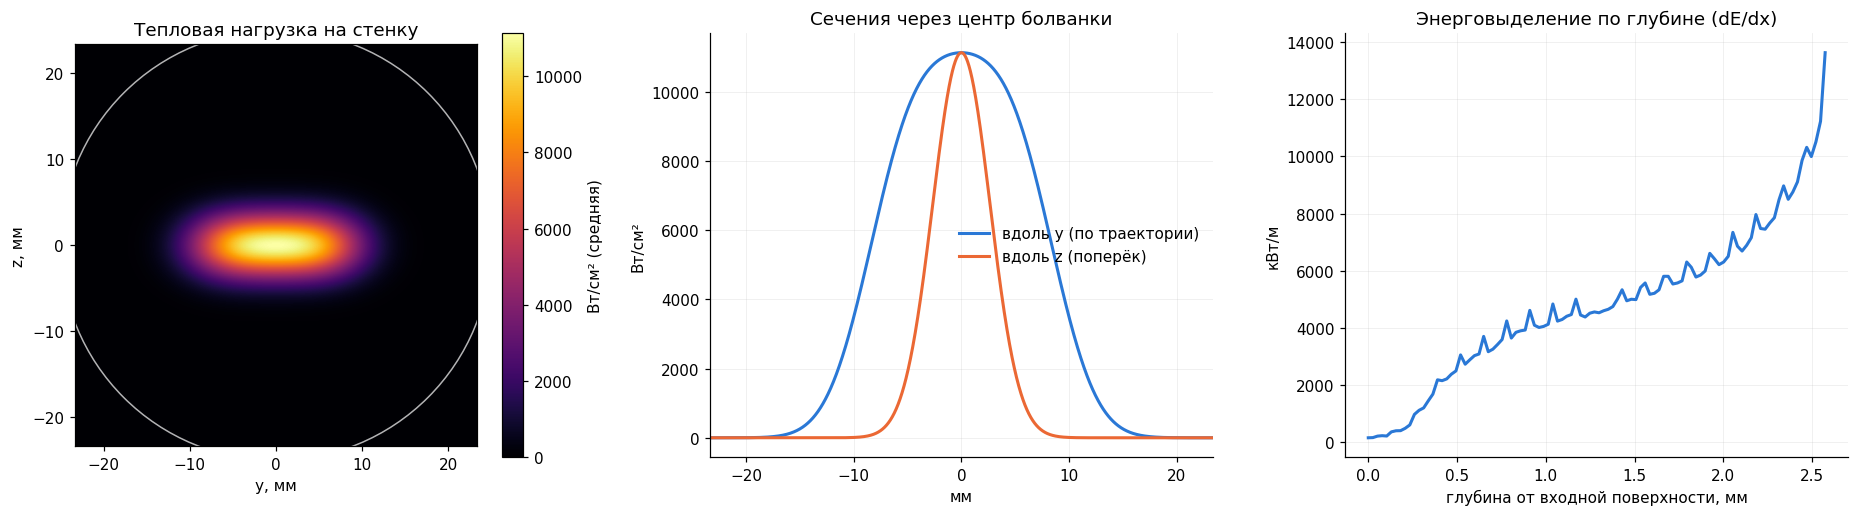

In [5]:
R_mm = meta["config"]["target"]["radius_mm"]
sweep_mm = meta.get("motion", {}).get("sweep_mm", 0.0)
ZOOM_MM = min(R_mm, 15.0 + sweep_mm / 2)    # масштаб картинки, мм

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), dpi=110)

ax = axes[0]
im = ax.pcolormesh(data["y_edges_mm"], data["z_edges_mm"], q_avg.T / 1e4,
                   cmap="inferno", shading="auto", rasterized=True)
ax.add_patch(plt.Circle((0, 0), R_mm, fill=False, color="white", lw=1.0, alpha=0.7))
ax.set(xlim=(-ZOOM_MM, ZOOM_MM), ylim=(-ZOOM_MM, ZOOM_MM),
       xlabel="y, мм", ylabel="z, мм", title="Тепловая нагрузка на стенку")
ax.set_aspect("equal")
fig.colorbar(im, ax=ax, label="Вт/см² (средняя)")

ax = axes[1]
iy0 = np.argmin(np.abs(data["y_mm"]))
iz0 = np.argmin(np.abs(data["z_mm"]))
ax.plot(data["y_mm"], q_avg[:, iz0] / 1e4, color="#2a78d6", lw=2,
        label="вдоль y (по траектории)")
ax.plot(data["z_mm"], q_avg[iy0, :] / 1e4, color="#eb6834", lw=2,
        label="вдоль z (поперёк)")
ax.legend(frameon=False)
ax.set(xlabel="мм", ylabel="Вт/см²", title="Сечения через центр болванки",
       xlim=(-ZOOM_MM, ZOOM_MM))
ax.grid(alpha=0.2, lw=0.6)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax = axes[2]
lin = data["lin_depth_total"] / M_PER_UNIT * (f_hit if kind == "J" else 1)   # Вт/м
x_shift = data["x_mm"] - data["x_mm"][0]
ax.plot(x_shift, lin / 1e3, color="#2a78d6", lw=2)
ax.set(xlabel="глубина от входной поверхности, мм", ylabel="кВт/м",
       title="Энерговыделение по глубине (dE/dx)")
ax.grid(alpha=0.2, lw=0.6)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

fig.tight_layout()
plt.show()

## 5. Выгрузка для COMSOL / ANSYS

Теплосъём идёт с той самой стенки, которая перпендикулярна оси пучка, поэтому источник
задаётся как **поверхностный тепловой поток** $q(y,z)$ [Вт/м²] по этой стенке — это ровно
та величина, что лежит в файле: энерговыделение, проинтегрированное по всей глубине мишени.

> **Приближение.** Вся мощность, выделившаяся в слое толщиной ~2.6 мм, «сажается» на стенку.
> Полный тепловой баланс и поперечное распределение при этом сохраняются точно, но перепад
> температуры поперёк этого слоя не описывается. Если понадобится температура самого
> бериллия по глубине, в файле есть профиль $dE/dx$ (`lin_depth_total`), и объёмный источник
> восстанавливается как $Q(x,y,z) = q(y,z)\cdot f(x)$, где $f$ — нормированная форма по
> глубине (выгружается ниже справочным файлом).

Выгружаются четыре небольших файла, **все в СИ: координаты в метрах, мощность средняя**:

| Файл | Что это | Для чего |
|---|---|---|
| `surface_yz_comsol_grid.txt` | $q(y,z)$, формат COMSOL Grid | интерполяционная функция 2 аргументов |
| `surface_xyz_ansys.csv` | $q$ с тремя координатами | ANSYS External Data (маппинг на грань) |
| `radial.csv` | $q(r)$, среднее по азимуту | грубая оценка для осесимметричных 2D-моделей |
| `depth_x_reference.csv` | $f(x)$, 1/м | справочно: проверить применимость приближения |

In [6]:
from scipy.ndimage import map_coordinates

# ======================= ПАРАМЕТРЫ ВЫГРУЗКИ =======================
EXPORT_STEP_MM = 0.25    # шаг сетки в выгружаемых файлах, мм
EXPORT_HALF_MM = None    # полуразмер области, мм (None — вся мишень)
WALL_X_MM = 0.0          # координата стенки теплосъёма в вашей модели, мм
                         # (нужна только для таблицы ANSYS)
# ==================================================================

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
half = EXPORT_HALF_MM or R_mm


def resample(q_map, y_mm, z_mm, targets_y_mm, targets_z_mm):
    # билинейная выборка карты на новую равномерную сетку
    iy = (targets_y_mm - y_mm[0]) / (y_mm[1] - y_mm[0])
    iz = (targets_z_mm - z_mm[0]) / (z_mm[1] - z_mm[0])
    IY, IZ = np.meshgrid(iy, iz, indexing="ij")
    return map_coordinates(q_map, np.stack([IY, IZ]), order=1, mode="constant", cval=0.0)


# --- сетка выгрузки ----------------------------------------------------------
n = int(round(2 * half / EXPORT_STEP_MM)) + 1
ye_mm = np.linspace(-half, half, n)
ze_mm = np.linspace(-half, half, n)
q_out = resample(q_avg, data["y_mm"], data["z_mm"], ye_mm, ze_mm)     # Вт/м²
ye_m, ze_m = ye_mm * 1e-3, ze_mm * 1e-3

# --- нормированная форма по глубине f(x), 1/м --------------------------------
dx_m = x_m[1] - x_m[0]
f_x = lin / (lin.sum() * dx_m)
x_rel_m = x_m - x_m[0] + dx_m / 2      # от входной поверхности мишени

print(f"сетка выгрузки : {n} x {n}, шаг {EXPORT_STEP_MM} мм")
print(f"проверка f(x)  : интеграл = {(f_x * dx_m).sum():.10f} (должен быть 1)")
print(f"проверка q     : интеграл по площади  = {q_out.sum() * (ye_m[1]-ye_m[0]) * (ze_m[1]-ze_m[0]):,.2f} Вт")
print(f"проверка dE/dx : интеграл по глубине  = {(lin * dx_m).sum():,.2f} Вт")
print(f"                 полная мощность      = {P_avg:,.2f} Вт")

сетка выгрузки : 201 x 201, шаг 0.25 мм
проверка f(x)  : интеграл = 1.0000000000 (должен быть 1)
проверка q     : интеграл по площади  = 12,544.90 Вт
проверка dE/dx : интеграл по глубине  = 12,544.90 Вт
                 полная мощность      = 12,544.90 Вт


In [7]:
def fmt_row(values):
    return " ".join(f"{v:.10e}" for v in values)


# --- 1. COMSOL Grid: q(y, z) -------------------------------------------------
path = EXPORT_DIR / "surface_yz_comsol_grid.txt"
with open(path, "w", encoding="utf-8") as fh:
    fh.write(f"% Энерговыделение в мишени, проинтегрированное по глубине\n")
    fh.write(f"% Аргументы: y, z в метрах. Функция: Вт/м² (средняя мощность)\n")
    fh.write(f"% Источник: {NPZ.name}, {meta['created']}\n")
    fh.write("% Grid\n")
    fh.write(fmt_row(ye_m) + "\n")
    fh.write(fmt_row(ze_m) + "\n")
    fh.write("% Data\n")
    for k in range(len(ze_m)):          # строка на каждое z, y меняется быстрее
        fh.write(fmt_row(q_out[:, k]) + "\n")
print(f"{path}  ({path.stat().st_size/2**10:.0f} КБ)")

# --- 2. CSV для ANSYS: координаты грани + поток ------------------------------
Y, Z = np.meshgrid(ye_m, ze_m, indexing="ij")
X = np.full(Y.size, WALL_X_MM * 1e-3)
path = EXPORT_DIR / "surface_xyz_ansys.csv"
np.savetxt(path, np.column_stack([X, Y.ravel(), Z.ravel(), q_out.ravel()]),
           delimiter=",", fmt="%.10e", header="x_m,y_m,z_m,q_W_per_m2", comments="")
print(f"{path}  ({path.stat().st_size/2**10:.0f} КБ, {q_out.size:,} строк)")

# --- 3. CSV: форма по глубине (справочно) ------------------------------------
path = EXPORT_DIR / "depth_x_reference.csv"
np.savetxt(path, np.column_stack([x_rel_m, f_x]),
           delimiter=",", fmt="%.10e", header="x_m,f_per_m", comments="")
print(f"{path}  ({len(f_x)} строк)")

# --- 4. CSV: радиальный профиль ----------------------------------------------
q_r = data["q_radial_mean"] / M_PER_UNIT**2 * (f_hit if kind == "J" else 1.0)
path = EXPORT_DIR / "radial.csv"
np.savetxt(path, np.column_stack([data["r_mm"] * 1e-3, q_r]),
           delimiter=",", fmt="%.10e", header="r_m,q_W_per_m2", comments="")
print(f"{path}  ({len(q_r)} строк)")

export/surface_yz_comsol_grid.txt  (679 КБ)
export/surface_xyz_ansys.csv  (2723 КБ, 40,401 строк)
export/depth_x_reference.csv  (100 строк)
export/radial.csv  (400 строк)


## 6. Как подключить в COMSOL

1. **Global Definitions → Functions → Interpolation**
   * *Data source*: `File`, файл `surface_yz_comsol_grid.txt`, *Data format*: `Grid`.
   * Имя функции, например `qs`. Получится функция двух аргументов `qs(y, z)`.
   * *Units*: Arguments — `m`, Function — `W/m^2`.
   * *Extrapolation*: `Specific number` = 0 (за пределами карты нагрева нет).
2. **Heat Transfer in Solids → Boundary Heat Source** (или `Heat Flux` →
   *General inward heat flux*) на стенке теплосъёма:
   ```
   Qb = qs(y, z)          [Вт/м²]
   ```
   Аргументы — координаты **в плоскости стенки**. Если в модели пучок идёт не вдоль `x`,
   переставьте их; если ось пучка смещена относительно начала координат, вычтите смещение:
   `qs(y - y0, z - z0)`.
3. **Проверка.** *Results → Derived Values → Surface Integration* от `qs(y,z)` по этой
   границе должен дать полную мощность, напечатанную выше (≈ 12.5 кВт для 20 МэВ).
   Если получилось меньше — скорее всего неверно заданы единицы аргументов.
4. **Импульсный режим.** Всё выгруженное — **средняя** мощность. Для нестационарного
   расчёта внутри импульса домножьте на прямоугольный импульс с амплитудой
   `1/duty = 100` и заполнением 100 мкс / 10 мс (функция `Rectangle` или `Events`).
   Среднее по периоду при этом сохранится.
5. **Осесимметричная (2D) постановка.** Осевой симметрии здесь нет: пучок эллиптический
   (σy ≠ σz), а при движении сборки пятно ещё и вытянуто вдоль траектории. `radial.csv`
   (среднее по азимуту) годится только как грубая оценка для неподвижной болванки —
   для движущейся он занижает нагрузку вдоль траектории и завышает поперёк неё.
   Используйте полную 2D-карту.

## Как подключить в ANSYS

1. **External Data** в Workbench → добавить `surface_xyz_ansys.csv`.
   * Разделитель — запятая, первая строка — заголовок.
   * Столбцы: `X`, `Y`, `Z` (единицы — **метры**) и `q_W_per_m2` как *Heat Flux* (`W/m^2`).
   * Координата `X` в файле — положение стенки, задаётся параметром `WALL_X_MM` в ячейке
     выгрузки; поставьте то значение, которое соответствует вашей геометрии.
2. Связать External Data с блоком **Steady-State / Transient Thermal**, в дереве выбрать
   грань теплосъёма → **Imported Load → Imported Heat Flux**.
3. В настройках маппинга: **Outside Option = 0** (вне выгруженной области нагрева нет),
   тип интерполяции `Triangulation` или `Kriging`.
4. После маппинга проверьте **Total Heat** по грани — он должен совпасть с полной
   мощностью, напечатанной выше.
5. Для импульсного режима то же замечание: в файле средняя мощность, внутри импульса она
   в `1/duty` раз выше.

## Допущения и что не учтено

* Энерговыделение **первичных + вторичных заряженных** частиц. Нейтроны и гамма-кванты
  уносят свою энергию из мишени и в этот источник не входят.
* Пучок считается параллельным (расходимость не учитывается), профиль — гауссов.
* Движение сборки за время импульса учтено как равномерное смещение болванки вдоль `y`,
  траектория отцентрована на болванке (зазоры с двух сторон одинаковые). Кривизна
  траектории на колесе не учитывается: на длине пути за импульс она пренебрежима.
* **Вся мощность приложена к стенке теплосъёма.** Баланс и поперечное распределение
  сохранены точно, перепад температуры поперёк слоя ~2.6 мм не описывается. Для оценки
  этого перепада есть `depth_x_reference.csv`: при пиковом потоке 2.25e8 Вт/м² и
  λ(Be) ≈ 200 Вт/(м·К) он составляет сотни кельвин, так что для температуры самого
  бериллия нужна объёмная постановка `Q = q(y,z)·f(x)`.
* Данные посчитаны для конкретной толщины мишени и энергии протонов — они указаны
  в паспорте расчёта выше.